### BPE (Byte Pair Encoding) 分词器:
一种基于数据压缩算法演变而来的子词（Subword）分词方法。它的核心思想是，通过**迭代式地合并最高频的相邻字节对（或字符对）**，来构建一个词汇表（Vocabulary）。使用这个词汇表，BPE 能够有效地将任何文本（包括未曾见过的词）切分为一系列已知的子词单元（Token），从而在控制词汇表大小和处理未知词（Out-of-Vocabulary, OOV）之间取得了出色的平衡。

与传统的按词或按字符切分不同，BPE 使得模型既能理解常见词作为一个整体，又能将稀有词或新词拆解为有意义的子词片段进行理解，极大地增强了语言模型的泛化能力。

---

### 推导过程详解

BPE 的工作原理分为两个主要阶段：**1. 词汇表构建（训练）** 和 **2. 文本编码（分词）**。

#### 阶段一：词汇表构建（训练）

这是 BPE 算法的核心。其目标是从一个大型语料库中学习出一套合并规则，并最终形成一个固定大小的词汇表。

**步骤 1：准备语料库和初始词汇表**
1.  **准备一个大型文本语料库**。
2.  将语料库中的所有单词拆分成最基础的单元——**字符序列**。为了区分单词边界，通常会在每个单词的末尾添加一个特殊的结束符，例如 `</w>`。
3.  **建立初始词汇表**：该词汇表包含语料库中出现的所有独立字符。

**一个简化的例子：**
假设我们的语料库是：
`{"low": 5, "lower": 2, "newest": 6, "widest": 3}`
（数字代表每个词在语料库中出现的频率）

初始拆分后得到：
*   `l o w </w>` : 5次
*   `l o w e r </w>` : 2次
*   `n e w e s t </w>` : 6次
*   `w i d e s t </w>` : 3次

初始词汇表为：`{l, o, w, e, r, n, s, t, i, d, </w>}`。

**步骤 2：迭代合并**
接下来，算法会重复执行以下操作，直到达到预设的词汇表大小（例如，30000个合并操作）：

1.  在整个语料库中，**统计所有相邻符号对（Pair）的出现频率**。
2.  **找出频率最高的那个符号对**，例如 `$ (A, B) $`。
3.  将这个符号对 `$ (A, B) $` 合并成一个新的、更大的符号 `$ AB $`。
4.  将这个新的符号 `$ AB $` 添加到词汇表中。
5.  在语料库的所有数据中，用新的符号 `$ AB $` 替换掉所有的 `$ (A, B) $` 对。
6.  返回第1步，继续下一轮迭代。

**继续我们的例子：**
*   **第 1 次合并**:
    *   最高频的相邻对是 `e` 和 `s`（来自 "newest" 和 "widest"），总共出现了 $6+3=9$ 次。
    *   我们合并 `e` 和 `s` 得到新符号 `es`。
    *   词汇表增加 `es`。
    *   语料库变为：`... n e w es t </w> ... w i d es t </w> ...`

*   **第 2 次合并**:
    *   此时，最高频的相邻对可能是 `es` 和 `t`（来自 "newest" 和 "widest"），总共出现了 $6+3=9$ 次。
    *   我们合并 `es` 和 `t` 得到新符号 `est`。
    *   词汇表增加 `est`。
    *   语料库变为：`... n e w est </w> ... w i d est </w> ...`

*   **第 3 次合并**:
    *   接下来，最高频的相邻对可能是 `l` 和 `o`（来自 "low" 和 "lower"），总共出现了 $5+2=7$ 次。
    *   合并得到 `lo`。
    *   ...

...这个过程会一直持续下去，直到完成预设的合并次数。最终，我们会得到一个包含初始字符和所有合并后产生的新子词的词汇表，以及一个记录了合并操作顺序的列表。

#### 阶段二：文本编码（分词）

当词汇表构建完成后，我们就可以用它来对任意新的文本进行分词。

**步骤：**
1.  将输入的单词同样拆分为字符序列，并在末尾加上结束符 `</w>`。
2.  **按照训练阶段学习到的合并规则的顺序**，依次在字符序列上进行合并。
3.  重复这个过程，直到无法再进行任何合并为止。
4.  最终得到的序列就是该单词的分词结果。

**例子：对新词 "lowest" 进行分词**
1.  **初始拆分**：`l`, `o`, `w`, `e`, `s`, `t`, `</w>`
2.  **应用合并规则**（假设我们已经学到了 `es` -> `est` 和 `lo` -> `low` 等规则）：
    *   查找是否有 `es`，有 -> 合并：`l`, `o`, `w`, `est`, `</w>`
    *   查找是否有 `lo`，有 -> 合并：`low`, `est`, `</w>`
    *   ...继续查找，直到没有可以应用的合并规则。
3.  **最终结果**：`lowest` 被分词为 `low` 和 `est`。

通过这种方式，即使 "lowest" 是一个从未在训练语料中出现过的词，BPE 也能利用已知的子词 `low` 和 `est` 来表示它。

---

### 其他分析视角

#### BPE 的优势
1.  **处理未知词（OOV）**：这是 BPE 最大的优势。任何新词都可以被拆解成已知的子词或单个字符的组合，不存在完全无法处理的词。
2.  **平衡词汇表大小和信息密度**：与单词级分词相比，BPE 的词汇表要小得多；与字符级分词相比，它的序列长度更短，信息密度更高，减少了模型的计算负担。
3.  **数据压缩**：其本质决定了它是一种高效的文本表示方式，高频词（如 "the"）或高频词根（如 "trans-"）可以被表示为单个 Token，从而压缩了序列长度。

#### BPE 的局限性
1.  **贪心策略的次优性**：BPE 每次都选择当前最优（频率最高）的字节对进行合并，这种贪心选择不一定能导向全局最优的分割结果。
2.  **语义的割裂**：BPE 的合并完全基于频率，不考虑语义。有时会将一个有完整语义的词切分成多个无实际意义的片段，例如 "transformer" 可能被切分为 `"trans"`, `"former"`，也可能被切分为 `"transform"`, `"er"`，甚至更奇怪的组合。
3.  **对多义词根不敏感**：同一个子词在不同上下文中可能有不同含义（例如 "apple" 中的 "app" 和 "application" 中的 "app"），但 BPE 会将它们视为同一个 Token。

#### 相关变体
*   **WordPiece**：由 Google 提出，用于 BERT。与 BPE 的主要区别在于，WordPiece 不是选择频率最高的相邻对，而是选择能使语料库的似然（Likelihood）提升最多的合并项。
*   **Unigram Language Model**：同样由 Google 提出，用于 T5、ALBERT 等。它从一个大的初始词汇表开始，通过评估移除每个子词对语言模型损失（Loss）的影响，逐步裁剪词汇表，更具概率意义。

---

In [ ]:
prompt = "the answer to the ultimate question of life, the universe, and everything is "
tokens = [128000] + tokenizer.encode(prompt)
print(tokens)
tokens = torch.tensor(tokens)
prompt_split_as_tokens = [tokenizer.decode([token.item()]) for token in tokens]
print(prompt_split_as_tokens)

用分词器处理输入

In [ ]:
embedding_layer = torch.nn.Embedding(vocab_size, dim)
embedding_layer.weight.data.copy_(model["tok_embeddings.weight"])
token_embeddings_unnormalized = embedding_layer(tokens).to(torch.bfloat16)
token_embeddings_unnormalized.shape

加载嵌入层，将输入转化为输入张量

In [ ]:
# def rms_norm(tensor, norm_weights):
#     rms = (tensor.pow(2).mean(-1, keepdim=True) + norm_eps)**0.5
#     return tensor * (norm_weights / rms)
def rms_norm(tensor, norm_weights):
    return (tensor * torch.rsqrt(tensor.pow(2).mean(-1, keepdim=True) + norm_eps)) * norm_weights

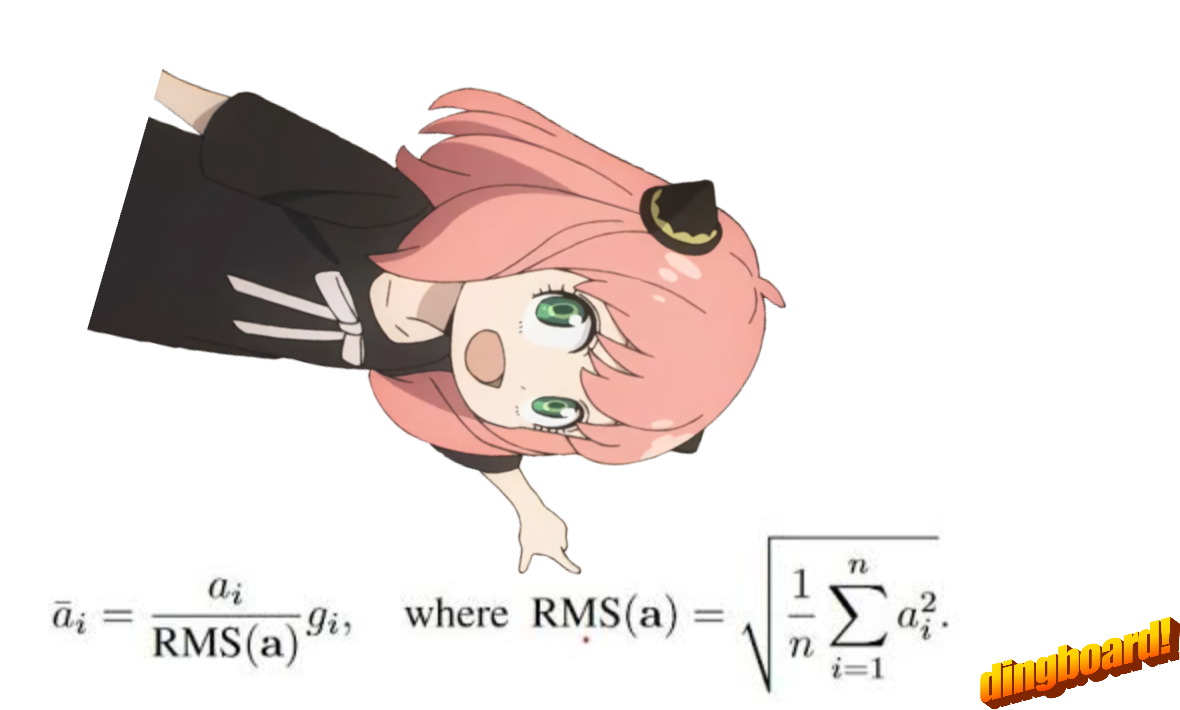
#### RMS归一化：相比LayerNorm省略去中心化（减去均值），只保留缩放。
缩放因子：每个元素平方然后去平均值再加一个极小的数（epsilon）来防止根号下为零，然后取根号

将输入除以缩放因子，然后乘以一个可学习矩阵，用来进一步提升缩放效果

In [ ]:
token_embeddings = rms_norm(token_embeddings_unnormalized, model["layers.0.attention_norm.weight"])
token_embeddings.shape

print(
    model["layers.0.attention.wq.weight"].shape,
    model["layers.0.attention.wk.weight"].shape,
    model["layers.0.attention.wv.weight"].shape,
    model["layers.0.attention.wo.weight"].shape
)

q_layer0 = model["layers.0.attention.wq.weight"]
head_dim = q_layer0.shape[0] // n_heads
q_layer0 = q_layer0.view(n_heads, head_dim, dim)
q_layer0.shape

映射矩阵（w_q\k\v）尺寸：torch.Size([4096, 4096]) torch.Size([1024, 4096]) torch.Size([1024, 4096]) torch.Size([4096, 4096])

重塑后的w_q：torch.Size([32, 128, 4096])

#### Transformer第一层的注意力头（分组查询注意力GQA）：
先将输入映射为Q、K、V矩阵

Q：32个头，每个头128维；K、V是8个头。有多组查询头，每组4个Q，每组共享同一套K、V

相比标准多头注意力MHA，可以减少K、V的头数

In [ ]:
q_layer0_head0 = q_layer0[0]
q_layer0_head0.shape

q_per_token = torch.matmul(token_embeddings, q_layer0_head0.T)
q_per_token.shape

一个头的w_q：torch.Size([128, 4096])

单个头的投影结果：torch.Size([17, 128])

Transformer是先整体映射，再分头；这里是先把权重分头，再分别映射

In [ ]:
q_per_token_split_into_pairs = q_per_token.float().view(q_per_token.shape[0], -1, 2)
q_per_token_split_into_pairs.shape

zero_to_one_split_into_64_parts = torch.tensor(range(64))/64
zero_to_one_split_into_64_parts

freqs = 1.0 / (rope_theta ** zero_to_one_split_into_64_parts)
freqs

freqs_for_each_token = torch.outer(torch.arange(17), freqs)
freqs_cis = torch.polar(torch.ones_like(freqs_for_each_token), freqs_for_each_token)
freqs_cis.shape

# viewing tjhe third row of freqs_cis
value = freqs_cis[3]
plt.figure()
for i, element in enumerate(value[:17]):
    plt.plot([0, element.real], [0, element.imag], color='blue', linewidth=1, label=f"Index: {i}")
    plt.annotate(f"{i}", xy=(element.real, element.imag), color='red')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.title('Plot of one row of freqs_cis')
plt.show()

q_per_token_as_complex_numbers = torch.view_as_complex(q_per_token_split_into_pairs)
q_per_token_as_complex_numbers.shape

q_per_token_as_complex_numbers_rotated = q_per_token_as_complex_numbers * freqs_cis
q_per_token_as_complex_numbers_rotated.shape

q_per_token_split_into_pairs_rotated = torch.view_as_real(q_per_token_as_complex_numbers_rotated)
q_per_token_split_into_pairs_rotated.shape

q_per_token_rotated = q_per_token_split_into_pairs_rotated.view(q_per_token.shape)
q_per_token_rotated.shape

## 旋转位置编码
把单个头的投影结果拆成[17, 64, 2]，即64个二维向量，每个二维向量会被当成一个复数

然后为每一对 (x, y)（每个二维子空间）分配一个不同的频率：[0/64, 1/64, ..., 63/64]；因为每个维度的向量旋转频率不同。低维度转的快。设置多种频率，是为了让模型能够在不同的“粒度”上感知和区分 token 之间的相对位置。高频关注局部细节，低频关注全局结构。

用位置乘以每一组向量的旋转频率，即可得到所有token每个维度的旋转角度。

将Q矩阵转为复数并执行旋转，然后再转回实数向量，最后压回[17, 128]

In [ ]:
qk_per_token = torch.matmul(q_per_token_rotated, k_per_token_rotated.T)/(head_dim)**0.5
qk_per_token.shape

#### K矩阵与Q矩阵类似，只是在分组查询注意力中，四个Q共用一个K，所以K只有8个头
#### 然后把Q、K乘起来得到注意力分数：[17, 17]
#### 后续与Transformer一致，先上三角掩码，然后softmax，再乘以V（一个头的尺寸是（17,128））得到注意力输出（17,128）
#### 得到一个Q头的输出后，同理遍历32个Q头，然后拼接起来（17， 4096），再通过一个线性层，得到完全的注意力结果：[17, 4096]
#### 最后再过一个归一化层

## SwiGLU前馈网络
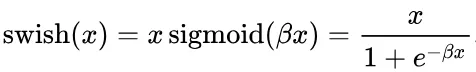
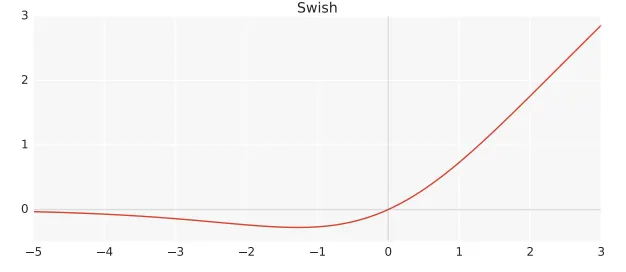
1.  **并行上投影 (Parallel Up-Projections)**：输入向量 `x` (维度为 `d_model`) **同时**被送入**两个不同**的线性层（我们称之为 `W1` 和 `W3`）。这两个线性层都将维度从 `d_model` 扩大到中间维度 `d_ffn`。
    *   路径 A： `H_gate = W1(x)`
    *   路径 B： `H_value = W3(x)`
    
    *注意：在 Llama 系列中，中间维度 `d_ffn` 通常不是 `4 * d_model`，而是 `2/3 * 4 * d_model`，这是一个设计选择。*

2.  **门控激活 (Gating Activation)**：
    *   对**路径 A** 的输出 `H_gate` 应用 **Swish** 激活函数。Swish 函数的公式是 `Swish(x) = x * sigmoid(x)`。它是一个平滑的、非单调的函数，与 ReLU 相比，它允许小的负值通过，并且梯度更平滑。
    *   `Gate = Swish(H_gate)`

3.  **门控操作 (Gating Operation)**：将**激活后的门 `Gate`** 与**路径 B** 的输出 `H_value` 进行**逐元素相乘 (element-wise multiplication)**。
    *   `Gated_output = Gate * H_value`
    *   这就是“门控”的核心：`Gate` 向量中的每个元素值（通常在 0 到 1 之间或附近）决定了 `H_value` 向量中对应元素有多少信息可以“通过”。如果 `Gate` 的某个元素接近 0，那么 `H_value` 对应位置的信息就被抑制；如果接近 1，信息就几乎无衰减地通过。因为 `Gate` 本身是由输入 `x` 计算得来的，所以这个“过滤”或“调节”过程是**动态的、内容相关的**。

4.  **下投影 (Down-Projection)**：将门控后的输出 `Gated_output`（维度为 `d_ffn`）送入最后一个线性层 `W2`，将其压缩回原始维度 `d_model`。
    *   `FFN_output = W2(Gated_output)`

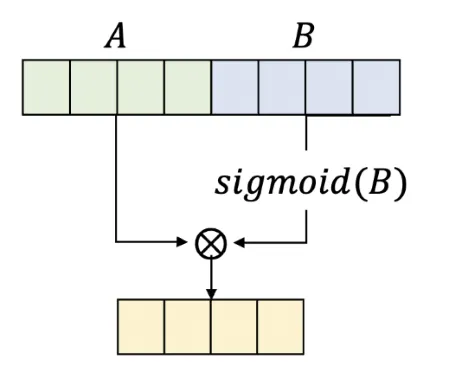

### **为什么 SwiGLU 更好？**

1.  **动态和内容相关的门控**：这是最重要的优势。与 ReLU 的静态“开关”不同，SwiGLU 的门是根据输入内容动态计算出来的。模型可以“学习”在不同的上下文中，哪些信息是重要的（让它通过），哪些是次要的（抑制它）。这提供了一种更精细、更灵活的信息流控制方式。

    *   **一个比喻**：ReLU 就像一个电灯开关，只有“开”和“关”。SwiGLU 就像一个智能调光器，它可以根据房间里的人、时间和活动，自动调节灯光的亮度，实现更复杂的光照效果。

2.  **表达能力更强**：由于其门控结构和更平滑的 Swish 激活函数，SwiGLU 网络能够学习比 ReLU 网络更复杂的函数和特征表示。逐元素相乘本身就是一种强大的非线性操作。

3.  **缓解梯度消失问题**：Swish 函数的导数比 ReLU 更平滑，没有在 0 点的突变。这有助于在深度网络中实现更稳定的梯度流，从而使训练过程更顺畅。

## 前馈层后：[17, 4096]

#### 然后堆叠32层上述网络结构，上一层输出作为下一层的输入。
#### 将最终的输出经过一个归一化
#### 然后是线性层（4096，128256）映射到词表尺寸——>（17，128256）
#### 取最后一个词元的输出（1，128256）来预测下一个值

In [ ]:
next_token = torch.argmax(logits, dim=-1)

用最大值函数取下一个token对应的编号